# Airport Route Analysis

Which airports combine healthy ticket prices, a mid-sized route network and efficient passenger density?
The notebook builds three filters (price, volume, density), intersects them into a shortlist, and then checks which popular destinations the shortlisted airports do not serve yet.

**Contents**
1. Ticket prices & market yield
2. Route competition & market concentration
3. Annual passenger density per airport
4. Final shortlist & hypothesis

## Setup

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [ ]:
routes = pd.read_csv("./clean_routes.csv")
traffic = pd.read_csv("./clean_air_traffic_2025.csv")
passengers = pd.read_csv("./clean_passengers.csv")

## Data overview

In [ ]:
routes.head()

,id,iata_from,iata_to,price,day1,day2,day3,day4,day5,day6,...,departure_country,departure_ICAO,departure_latitude,departure_longitude,departure_altitude,arrival_ICAO,arrival_latitude,arrival_longitude,arrival_altitude,departure_total_passengers
0,18135,HAJ,AYT,110,yes,yes,yes,yes,yes,yes,...,Germany,EDDV,52.461102,9.68508,183,LTAI,36.898701,30.800501,177.0,5386.865
1,18176,HAJ,MUC,140,yes,yes,yes,yes,yes,yes,...,Germany,EDDV,52.461102,9.68508,183,EDDM,48.353802,11.786100,1487.0,5386.865
2,18157,HAJ,FRA,140,yes,yes,yes,yes,yes,yes,...,Germany,EDDV,52.461102,9.68508,183,EDDF,50.033333,8.570556,364.0,5386.865
3,18132,HAJ,AMS,150,yes,yes,yes,yes,yes,yes,...,Germany,EDDV,52.461102,9.68508,183,EHAM,52.308601,4.763890,-11.0,5386.865
4,18197,HAJ,VIE,160,yes,yes,yes,yes,yes,yes,...,Germany,EDDV,52.461102,9.68508,183,LOWW,48.110298,16.569700,600.0,5386.865


In [ ]:
traffic.head()

,icao_code,airport_city,country,month_num,month_mon,departures,arrivals,total_flights
0,BIKF,Keflavik,Iceland,1,JAN,1892,1887,3779
1,BIKF,Keflavik,Iceland,2,FEB,1918,1927,3845
2,BIKF,Keflavik,Iceland,3,MAR,2258,2265,4523
3,BIKF,Keflavik,Iceland,4,APR,2567,2574,5141
4,BIKF,Keflavik,Iceland,5,MAY,2928,2927,5855


In [ ]:
passengers.head()

,airport,country,mean,total,name,municipality
0,LFPG,France,6038.785900,72465.430800,Charles de Gaulle International Airport,"Paris (Roissy-en-France, Val-d'Oise)"
1,LEMD,Spain,5736.871000,68842.452000,Adolfo Suárez Madrid–Barajas Airport,Madrid
2,EHAM,Netherlands,5705.252500,68463.030000,Amsterdam Airport Schiphol,Amsterdam
3,EDDF,Germany,5234.043500,62808.522000,Frankfurt Main Airport,Frankfurt am Main
4,LEBL,Spain,4815.955818,57791.469818,Josep Tarradellas Barcelona-El Prat Airport,Barcelona


In [ ]:
routes.columns

Index(['id', 'iata_from', 'iata_to', 'price', 'day1', 'day2', 'day3', 'day4',
       'day5', 'day6', 'day7', 'flights_per_day', 'common_duration',
       'flights_per_week', 'first_flight', 'last_flight', 'airlineroutes',
       'arrival_airport_country_code', 'arrival_airport_name',
       'arrival_airport_city_name', 'arrival_airport_city_name_en',
       'arrival_airport_country', 'arrival_airport_no_routes',
       'departure_city', 'departure_country', 'departure_ICAO',
       'departure_latitude', 'departure_longitude', 'departure_altitude',
       'arrival_ICAO', 'arrival_latitude', 'arrival_longitude',
       'arrival_altitude', 'departure_total_passengers'],
      dtype='str')

## 1. Ticket prices & market yield

### 1.1 Mean price and number of routes per airport

In [ ]:
# Calculate the mean price per airport
mean_prices = routes.groupby('iata_from')['price'].mean().sort_values(ascending=False).reset_index()

mean_prices.head(10)

,iata_from,price
0,SVQ,449.438202
1,CDG,325.306859
2,GRQ,320.000000
3,AMS,300.786517
4,ZRH,289.905213
5,FRA,277.403509
6,LGG,276.000000
7,LPA,252.900763
8,HEL,240.703125
9,MUC,238.427948


In [ ]:
# Calculate the amount of routes per airport
amount_routes = (routes.groupby('iata_from')['iata_from'].count().sort_values(ascending=False).reset_index(name='count'))

amount_routes.head()

,iata_from,count
0,FRA,285
1,CDG,277
2,AMS,267
3,FCO,235
4,MUC,229


### 1.2 Candidate airports by price

Filter: between 10 and 200 routes **and** mean ticket price above $150.

In [ ]:
# Group routes and calculate average price per airport
quote_stats = routes.groupby('iata_from').agg(route_count=('iata_from', 'count'),mean_price=('price', 'mean')).reset_index()

# Filter airports between 10 and 200 routes
price_route_table = quote_stats[(quote_stats['route_count'] >= 10) & (quote_stats['route_count'] <= 200) & (quote_stats['mean_price'] > 150)].sort_values(by='mean_price', ascending=False).reset_index(drop=True)

price_route_table

,iata_from,route_count,mean_price
0,SVQ,89,449.438202
1,LPA,131,252.900763
2,HEL,128,240.703125
3,KEF,95,218.210526
4,LIS,148,215.000000
5,PDL,33,199.696970
6,SMI,15,195.333333
7,OPO,132,194.772727
8,BOD,90,183.444444
9,BRU,169,175.325444


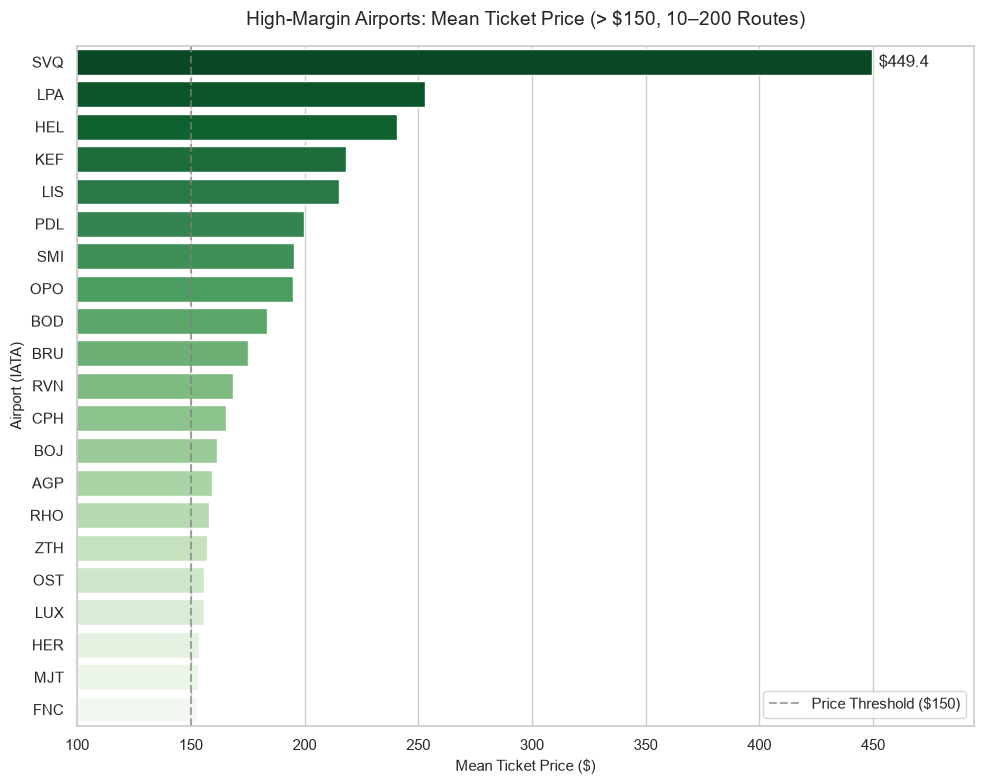

In [ ]:
plt.figure(figsize=(10, 8))

# Sort by mean_price to display highest pricing airports at the top
price_route_table_sorted = price_route_table.sort_values(by="mean_price", ascending=False)

# Horizontal bar chart for clean label reading
ax = sns.barplot(
    data=price_route_table_sorted,
    x="mean_price",
    y="iata_from",
    hue="iata_from",
    legend=False,
    palette="Greens_r",
)

# Reference line for your pricing threshold (> 150)
plt.axvline(150, color="gray", linestyle="--", alpha=0.7, label="Price Threshold ($150)")

# Titles and labels
plt.title(
    "High-Margin Airports: Mean Ticket Price (> $150, 10–200 Routes)",
    fontsize=14,
    pad=15,
)
plt.xlabel("Mean Ticket Price ($)", fontsize=11)
plt.ylabel("Airport (IATA)", fontsize=11)

# Set x-limits with padding so data labels fit cleanly
max_price = price_route_table_sorted["mean_price"].max()
plt.xlim(100, max_price * 1.1)

# Add data labels to bars ($ format)
ax.bar_label(ax.containers[0], fmt="$%.1f", padding=5)

plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

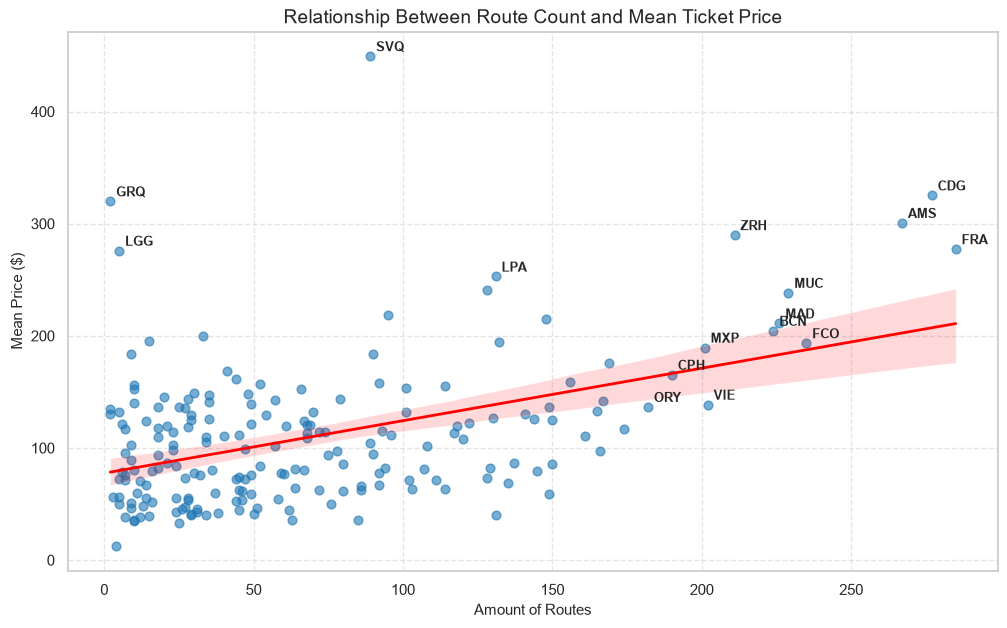

In [ ]:
plt.figure(figsize=(12, 7))

# 1. Scatter plot
sns.regplot(
    data=quote_stats,
    x='route_count',
    y='mean_price',
    scatter_kws={'alpha': 0.6, 's': 40, 'color': '#1f77b4'},
    line_kws={'color': 'red', 'linewidth': 2}
)

# 2. Filter to label key airports (e.g., > 180 routes OR > $250 mean price)
hubs = quote_stats[
    (quote_stats['route_count'] > 180) | (quote_stats['mean_price'] > 250)
]

# 3. Add text labels with a slight offset
for _, row in hubs.iterrows():
    plt.text(
        row['route_count'] + 2,   # Shift right by 2 units
        row['mean_price'] + 2,    # Shift up by 2 units
        str(row['iata_from']),
        fontsize=9,
        fontweight='bold',
        va='bottom'
    )

plt.title('Relationship Between Route Count and Mean Ticket Price', fontsize=14)
plt.xlabel('Amount of Routes', fontsize=11)
plt.ylabel('Mean Price ($)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### 1.3 Price statistics per airport

In [ ]:
airport_pricing = (
    routes.groupby("iata_from")
    .agg(
        total_routes=("iata_from", "count"),
        mean_price=("price", "mean"),
        median_price=("price", "median"),
        std_price=("price", "std")
    )
    .reset_index()
    .assign(
        price_per_route=lambda df: df["mean_price"] / df["total_routes"]
    )
)

In [ ]:
airport_pricing.sort_values("median_price", ascending=False).head(15)

In [ ]:
airport_pricing.head(20).sort_values("price_per_route", ascending=False)

,iata_from,total_routes,mean_price,median_price,std_price,price_per_route
9,ANR,9,183.333333,180.0,71.239034,20.370370
3,AES,9,88.888889,100.0,58.831209,9.876543
0,AAL,14,124.285714,95.0,97.089513,8.877551
19,BIA,35,147.428571,120.0,112.781487,4.212245
6,AJA,24,84.166667,70.0,81.822537,3.506944
10,AOI,16,51.875000,35.0,49.560569,3.242188
1,AAR,12,38.333333,25.0,46.677488,3.194444
16,BES,27,73.333333,70.0,40.667507,2.716049
17,BGO,67,124.029851,110.0,113.030697,1.851192
14,BDS,44,72.500000,50.0,74.961230,1.647727


**Hubs** (airports with at least 10 routes)

In [ ]:
hub_pricing= airport_pricing[airport_pricing["total_routes"] >= 10]

In [ ]:
hub_pricing.sort_values("std_price", ascending=False)

,iata_from,total_routes,mean_price,median_price,std_price,price_per_route
160,SVQ,89,449.438202,50.0,2308.444163,5.049867
102,LPA,131,252.900763,110.0,1363.712968,1.930540
24,BOD,90,183.444444,40.0,1184.801848,2.038272
13,BCN,224,204.553571,50.0,1031.386709,0.913186
4,AGP,156,159.166667,60.0,968.088878,1.020299
...,...,...,...,...,...,...
34,BVA,85,36.000000,30.0,22.424476,0.423529
40,CIA,31,42.580645,40.0,20.811494,1.373569
109,MMX,10,35.000000,40.0,20.682789,3.500000
78,HHN,51,46.274510,40.0,20.293919,0.907343


In [ ]:
top_pricing_hubs = hub_pricing.sort_values(
    by="median_price", ascending=False
)
top_pricing_hubs.head(10)

,iata_from,total_routes,mean_price,median_price,std_price,price_per_route
153,SMI,15,195.333333,200.0,144.611137,13.022222
193,ZRH,211,289.905213,190.0,263.248914,1.373958
85,KEF,95,218.210526,180.0,183.459538,2.296953
8,AMS,267,300.786517,170.0,286.466251,1.126541
107,MJT,10,153.000000,165.0,79.589223,15.300000
62,FRA,285,277.403509,160.0,225.473513,0.973346
76,HEL,128,240.703125,160.0,238.898996,1.880493
130,PDL,33,199.696970,150.0,151.358119,6.051423
113,MUC,229,238.427948,150.0,216.428689,1.041170
25,BOJ,44,161.363636,145.0,114.457079,3.667355


**Sanity checks** — SVQ has a mean price far above its median (possible price outliers), and a few airports have a standard deviation of 0 (all routes priced the same).

In [ ]:
airport_pricing.loc[airport_pricing["iata_from"] == "SVQ"]

,iata_from,total_routes,mean_price,median_price,std_price,price_per_route
160,SVQ,89,449.438202,50.0,2308.444163,5.049867


In [ ]:
airport_pricing.std_price.min()

np.float64(0.0)

In [ ]:
airport_pricing.loc[airport_pricing["std_price"] == 0]

,iata_from,total_routes,mean_price,median_price,std_price,price_per_route
179,VAA,2,130.0,130.0,0.0,65.0


## 2. Route competition & market concentration

Filter: between 10 and 200 routes **and** mean departure passengers between 10,000 and 40,000.

In [ ]:
# 1. Group and calculate statistics
volume_stats = routes.groupby('iata_from').agg(
    amount_routes=('iata_from', 'count'),
    passengers_volume=('departure_total_passengers', 'mean')
).reset_index()

# 2. Apply filters
volume_routes = volume_stats[
    (volume_stats['amount_routes'] >= 10) &
    (volume_stats['amount_routes'] <= 200) &
    (volume_stats['passengers_volume'] >= 10000) &
    (volume_stats['passengers_volume'] <= 40000)
].sort_values(by='passengers_volume', ascending=False).reset_index(drop=True)

volume_routes

,iata_from,amount_routes,passengers_volume
0,LIS,148,36371.420400
1,ORY,182,35428.366800
2,ATH,167,34316.096727
3,PMI,166,33563.358545
4,CPH,190,33389.171000
5,OSL,150,27089.562000
6,AGP,156,26869.380000
7,BER,161,25871.923000
8,ARN,165,24939.288000
9,WAW,141,24579.264000


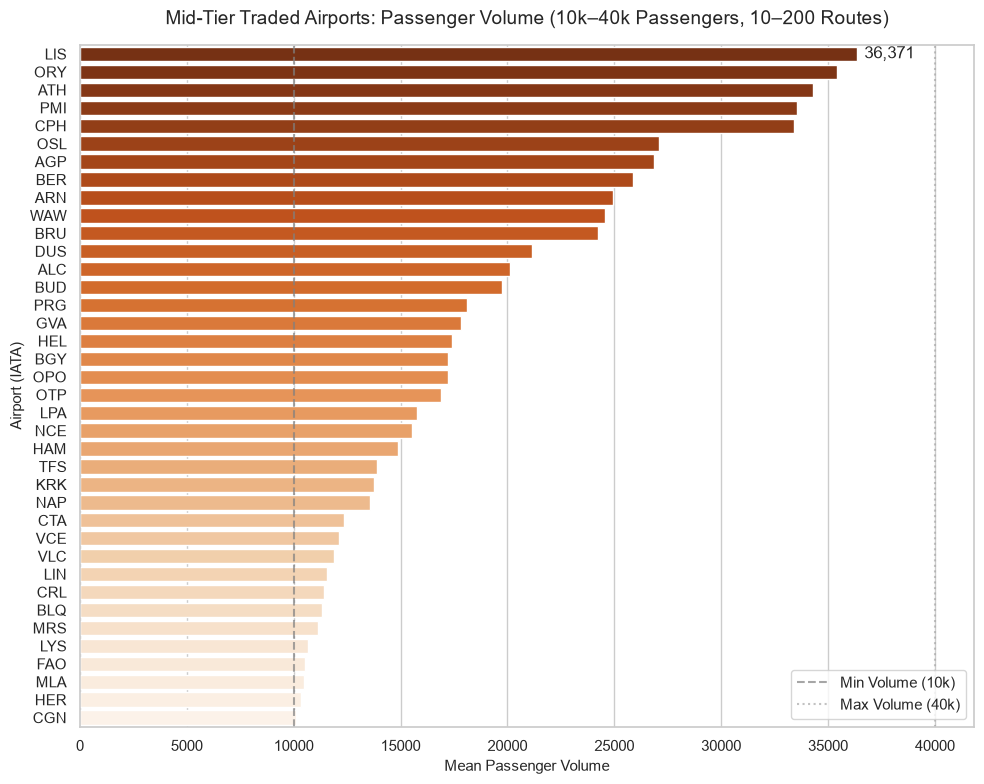

In [ ]:
plt.figure(figsize=(10, 8))

# Ensure sorting by passenger volume for clean top-to-bottom rendering
volume_routes_sorted = volume_routes.sort_values(by="passengers_volume", ascending=False)

# Horizontal bar chart
ax = sns.barplot(
    data=volume_routes_sorted,
    x="passengers_volume",
    y="iata_from",
    hue="iata_from",
    legend=False,
    palette="Oranges_r",
)

# Reference lines for your volume thresholds (10k - 40k)
plt.axvline(
    10000, color="gray", linestyle="--", alpha=0.7, label="Min Volume (10k)"
)
plt.axvline(
    40000, color="darkgray", linestyle=":", alpha=0.7, label="Max Volume (40k)"
)

# Titles and labels
plt.title(
    "Mid-Tier Traded Airports: Passenger Volume (10k–40k Passengers, 10–200 Routes)",
    fontsize=14,
    pad=15,
)
plt.xlabel("Mean Passenger Volume", fontsize=11)
plt.ylabel("Airport (IATA)", fontsize=11)

# Dynamic x-axis limits to accommodate bar annotations smoothly
max_vol = volume_routes_sorted["passengers_volume"].max()
plt.xlim(0, max_vol * 1.15)

# Add comma-formatted number labels to bars
ax.bar_label(ax.containers[0], fmt="{:,.0f}", padding=5)

plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [ ]:
volume_stats['volume_per_route'] = (
    volume_stats['passengers_volume'] * 1000 / volume_stats['amount_routes']
)

top_10_volume = volume_stats.sort_values(by='volume_per_route', ascending=False).head(10)
top_10_volume = top_10_volume[['iata_from', 'amount_routes', 'passengers_volume', 'volume_per_route']]

top_10_volume

,iata_from,amount_routes,passengers_volume,volume_per_route
105,MAD,226,68842.452000,304612.619469
36,CDG,277,72465.430800,261608.053430
13,BCN,224,57791.469818,257997.633117
8,AMS,267,68463.030000,256415.842697
99,LIS,148,36371.420400,245752.840541
164,TFN,32,7210.753091,225336.034091
98,LIN,52,11551.530000,222144.807692
62,FRA,285,62808.522000,220380.778947
55,FCO,235,50858.531000,216419.280851
12,ATH,167,34316.096727,205485.609145


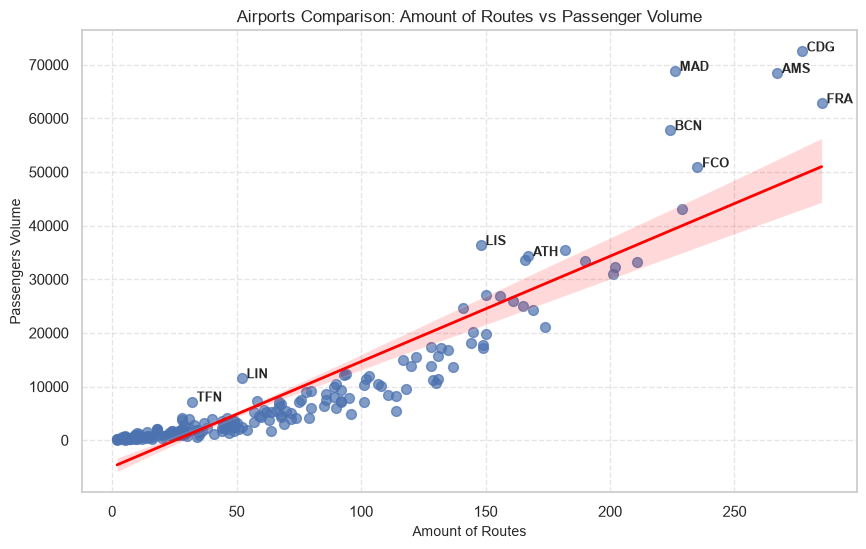

In [ ]:
plt.figure(figsize=(10, 6))

# Scatter plot with regression line across all airports
sns.regplot(
    data=volume_stats,
    x='amount_routes',
    y='passengers_volume',
    scatter_kws={'alpha': 0.7, 's': 50},
    line_kws={'color': 'red', 'linewidth': 2}
)

# Annotate Top 10 airports on the plot for clarity
for _, row in top_10_volume.iterrows():
    plt.text(
        row['amount_routes'] + 2,
        row['passengers_volume'],
        row['iata_from'],
        fontsize=9,
        fontweight='bold'
    )

plt.title('Airports Comparison: Amount of Routes vs Passenger Volume', fontsize=12)
plt.xlabel('Amount of Routes', fontsize=10)
plt.ylabel('Passengers Volume', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

## 3. Annual passenger density per airport

Density = annual passengers per flight. Flights come from the traffic table (ICAO code), passengers from the passengers table.

In [ ]:
# Total annual flights per airport, matching name to passenger data frame
annual_flights_df = (traffic.groupby("icao_code", as_index=False)["total_flights"].sum().rename(columns={"icao_code": "airport", "total_flights": "annual_flights"}))

In [ ]:
# Merge passenger totals with flight totals
density = (
    annual_flights_df
    .merge(passengers[['airport', 'total']], on='airport', how='inner')
    .rename(columns={'total': 'annual_passengers'})
)

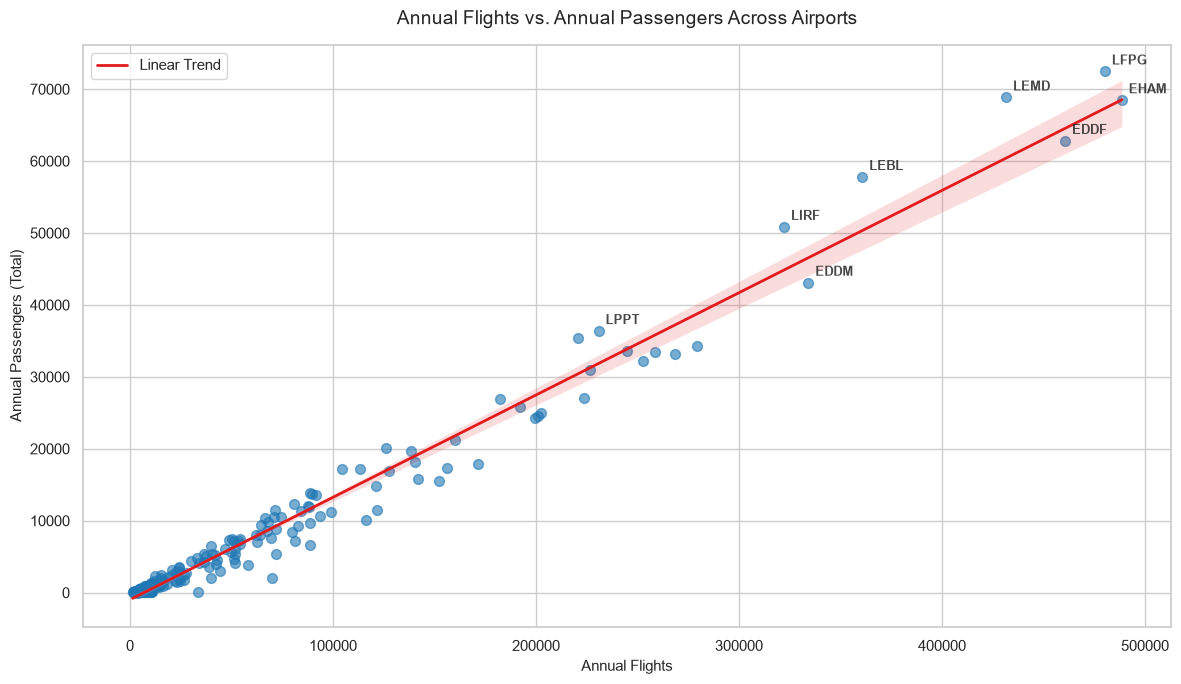

In [ ]:
plt.figure(figsize=(12, 7))

# Create scatter plot with linear regression trendline
ax = sns.regplot(
    data=density,
    x="annual_flights",
    y="annual_passengers",
    scatter_kws={"alpha": 0.6, "color": "#1f77b4", "s": 50},
    line_kws={"color": "#e31a1c", "linewidth": 2, "label": "Linear Trend"},
)

# Annotate top/key airports for visual context (e.g., LSZH, EBBR)
top_airports = density.sort_values(by="annual_passengers", ascending=False).head(8)
for _, row in top_airports.iterrows():
    ax.annotate(
        text=row["airport"],
        xy=(row["annual_flights"], row["annual_passengers"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        alpha=0.85,
    )

# Formatting title and labels
plt.title(
    "Annual Flights vs. Annual Passengers Across Airports",
    fontsize=14,
    pad=15,
)
plt.xlabel("Annual Flights", fontsize=11)
plt.ylabel("Annual Passengers (Total)", fontsize=11)

plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
density['pass_density'] = (
    density['annual_passengers'] * 1000 / density['annual_flights']
).round(2)

density = density.sort_values(by='pass_density', ascending=False).reset_index(drop=True)
density.head(10)

,airport,annual_flights,annual_passengers,pass_density
0,EPMO,12573,2356.699000,187.44
1,LIME,104642,17233.121000,164.69
2,LGZA,15190,2455.161818,161.63
3,LFOB,39821,6431.630400,161.51
4,LFPO,220599,35428.366800,160.60
5,LEBL,360772,57791.469818,160.19
6,EBCI,71692,11437.412400,159.54
7,LEMD,431626,68842.452000,159.50
8,LEAL,126266,20123.520000,159.37
9,LIRF,322236,50858.531000,157.83


### Reading the density ranking

**High utilization:** airports with density > 150 demonstrate strong passenger demand and efficient seat filling.

**Identifying the sweet spot**
- Ultra-large hubs like LEMD (431k flights) or LEBL (360k flights) have high density but face heavy congestion, slot constraints, and established legacy carrier dominance.
- Mid-sized airports like EPMO (12.5k flights), LGZA (Zakynthos, 15.2k flights), or LFOB (39.8k flights) demonstrate high demand per flight without the massive operational congestion of mega-hubs.
- Airports near or above 185+ (EPMO at 187.4) suggest near-total single-carrier saturation at maximum seat capacity, indicating either high spill or operations constrained by fleet sizing.

Filter used below: density between 155 and 185.

In [ ]:
healthy_density = (density[(density["pass_density"] >= 155) & (density["pass_density"] <= 185)].sort_values(by="pass_density", ascending=False).reset_index(drop=True))
healthy_density

,airport,annual_flights,annual_passengers,pass_density
0,LIME,104642,17233.121000,164.69
1,LGZA,15190,2455.161818,161.63
2,LFOB,39821,6431.630400,161.51
3,LFPO,220599,35428.366800,160.60
4,LEBL,360772,57791.469818,160.19
5,EBCI,71692,11437.412400,159.54
6,LEMD,431626,68842.452000,159.50
7,LEAL,126266,20123.520000,159.37
8,LIRF,322236,50858.531000,157.83
9,LPPT,230897,36371.420400,157.52


In [ ]:
# Map ICAO codes to IATA codes so the table can be joined with the other filters
airport_mapping = routes[['departure_ICAO', 'iata_from']].drop_duplicates()

healthy_density = (
    healthy_density
    .merge(airport_mapping, left_on='airport', right_on='departure_ICAO', how='left')
    .drop(columns=['departure_ICAO', 'airport'])
)

# Move iata_from to the leftmost position
iata_col = healthy_density.pop('iata_from')
healthy_density.insert(0, 'iata_from', iata_col)

healthy_density

,iata_from,annual_flights,annual_passengers,pass_density
0,BGY,104642,17233.121000,164.69
1,ZTH,15190,2455.161818,161.63
2,BVA,39821,6431.630400,161.51
3,ORY,220599,35428.366800,160.60
4,BCN,360772,57791.469818,160.19
5,CRL,71692,11437.412400,159.54
6,MAD,431626,68842.452000,159.50
7,ALC,126266,20123.520000,159.37
8,FCO,322236,50858.531000,157.83
9,LIS,230897,36371.420400,157.52


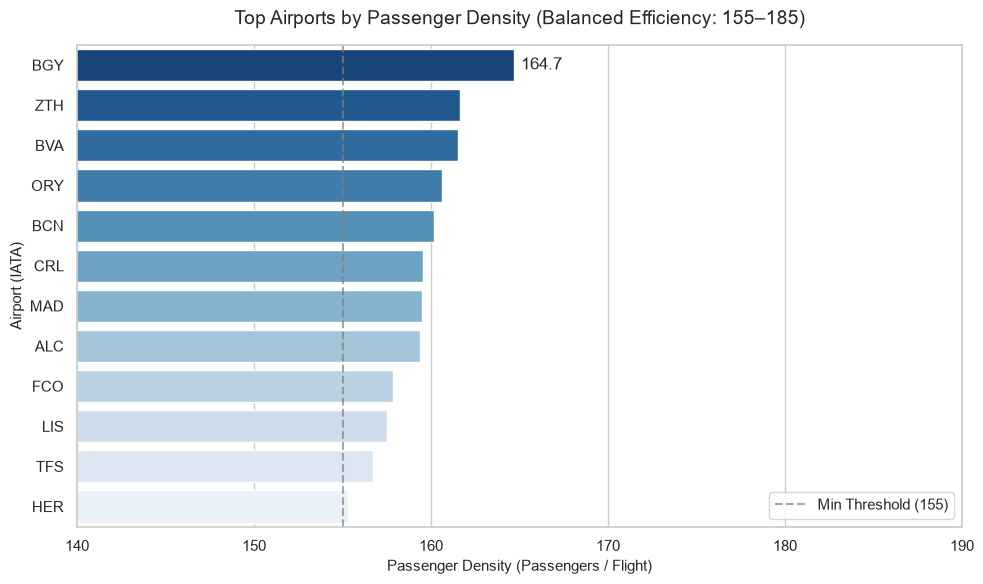

In [ ]:
plt.figure(figsize=(10, 6))

# Horizontal bar chart for clean label reading
ax = sns.barplot(
    data=healthy_density,
    x="pass_density",
    y="iata_from",
    hue="iata_from",
    legend=False,
    palette="Blues_r",
)

# Reference line for narrowbody capacity benchmark
plt.axvline(
    155, color="gray", linestyle="--", alpha=0.7, label="Min Threshold (155)"
)

# Titles and labels
plt.title(
    "Top Airports by Passenger Density (Balanced Efficiency: 155–185)",
    fontsize=14,
    pad=15,
)
plt.xlabel("Passenger Density (Passengers / Flight)", fontsize=11)
plt.ylabel("Airport (IATA)", fontsize=11)
plt.xlim(140, 190)

# Add data labels to bars
ax.bar_label(ax.containers[0], fmt="%.1f", padding=5)

plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 4. Final shortlist & hypothesis

Airports that pass **all three** filters (price, volume, density).

In [ ]:
# Perform inner joins sequentially on 'iata_from'
recommended_airports = (price_route_table.merge(volume_routes, on='iata_from', how='inner').merge(healthy_density, on='iata_from', how='inner'))

print(f"Airports meeting all criteria: {len(recommended_airports)}")
recommended_airports.head()

Airports meeting all criteria: 2


,iata_from,route_count,mean_price,amount_routes,passengers_volume,annual_flights,annual_passengers,pass_density
0,LIS,148,215.000000,148,36371.420400,230897,36371.420400,157.52
1,HER,101,153.564356,101,10342.363636,66601,10342.363636,155.29


### Which popular destinations are not served from the shortlisted airports?

Popular destinations = the 20 most frequent `iata_to` values in the routes table.

In [ ]:
top_destinations = routes['iata_to'].value_counts().reset_index()
top_destinations.columns = ['iata_to', 'route_count']

top_destinations.head(10)

,iata_to,route_count
0,STN,130
1,FRA,124
2,MUC,123
3,FCO,120
4,AMS,119
5,BCN,119
6,MAN,119
7,CPH,114
8,PMI,113
9,DUB,113


In [ ]:
# Top 20 most popular destinations
popular_destinations = set(routes['iata_to'].value_counts().head(20).index)

# Get existing destinations currently served from LIS and HER
served_from_lis = set(routes.loc[routes['iata_from'] == 'LIS', 'iata_to'].unique())
served_from_her = set(routes.loc[routes['iata_from'] == 'HER', 'iata_to'].unique())

# Find missing routes using set difference (-)
unserved_lis = popular_destinations - served_from_lis
unserved_her = popular_destinations - served_from_her

print('Popular destinations NOT served from LIS:', sorted(unserved_lis))
print('Popular destinations NOT served from HER:', sorted(unserved_her))

Popular destinations NOT served from LIS: []
Popular destinations NOT served from HER: ['AGP', 'ALC', 'MAD', 'PMI']
